# Бинарная классификация

## 1. Импорт библиотек и загрузка данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score,
  f1_score, roc_auc_score, confusion_matrix,
  ConfusionMatrixDisplay, roc_curve
)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
print('Библиотеки загружены успешно')

Библиотеки загружены успешно


In [ ]:
import io
import requests

# Датасет: Banking Customer Details with Credit Ratings
# Источник: https://www.kaggle.com/code/shivamagarwal29/credit-risk/notebook
# Файл размещён на Google Drive с открытым доступом
file_id = '13FqgGun6ip9dNq3sNcRg2Y76xCppOrpD'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

response = requests.get(url)
df = pd.read_csv(io.StringIO(response.content.decode('latin-1')))

print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')
print()
display(df.head())

Датасет загружен: 1150 строк, 9 столбцов



,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


**Описание признаков:**
- `age` — возраст клиента
- `ed` — уровень образования клиента
- `employ` — опыт работы (лет)
- `address` — адрес клиента
- `income` — годовой доход клиента
- `debtinc` — соотношение долга к доходу: например, значение 10 означает, что долг клиента составляет 10% от его годового дохода.
- `creddebt` — соотношение кредита к долгу
- `othdebt` — прочие задолженности
- `default` — целевая переменная: допускал ли клиент дефолт в прошлом (1 = да, 0 = никогда)

> **Дефолт по кредиту** — это ситуация, когда заёмщик не смог выполнить свои обязательства перед банком: прекратил вносить платежи в установленный срок. Для банка это означает прямые финансовые потери. Задача модели — по характеристикам клиента заранее определить, высок ли риск того, что он не вернёт кредит.

## 2. Предобработка данных

### 2.1 Общая статистика по данным

In [ ]:
print('Типы данных и пропуски:')
print(df.dtypes)
print()
print('Пропущенные значения по столбцам:')
print(df.isnull().sum())

Типы данных и пропуски:
age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object

Пропущенные значения по столбцам:
age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     450
dtype: int64


In [ ]:
display(df.describe().round(2))

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,1150.00,1150.00,1150.00,1150.00,1150.00,1150.00,1150.00,1150.00,700.00
mean,35.24,1.70,8.78,8.49,47.98,10.06,1.61,3.10,0.26
std,8.09,0.93,6.91,6.98,40.51,6.58,2.14,3.53,0.44
min,20.00,1.00,0.00,0.00,13.00,0.10,0.01,0.05,0.00
25%,29.00,1.00,3.00,3.00,24.00,5.20,0.42,1.05,0.00
50%,35.00,1.00,7.00,7.00,36.00,8.75,0.90,2.04,0.00
75%,41.00,2.00,13.00,12.00,56.75,13.60,1.90,3.86,1.00
max,56.00,5.00,33.00,34.00,446.00,41.30,20.56,35.20,1.00


Таблица `describe()` даёт первое представление о данных: средние значения, разброс, минимум и максимум по каждому признаку. Сразу обращают на себя внимание большие значения максимумов у `income` (до 446), `creddebt` и `othdebt` — это сигнал о возможных выбросах, которые нужно проверить отдельно. Также видно, что у `default` count = 700 вместо 1150, то есть 450 строк не имеют метки и не могут использоваться в обучении.

### 2.2 Удаление строк без метки целевой переменной

In [ ]:
df_clean = df.dropna(subset=['default']).copy()
df_clean['default'] = df_clean['default'].astype(int)

print(f'Строк после удаления пропусков в целевой переменной: {len(df_clean)}')
print()
print('Распределение классов:')
counts = df_clean['default'].value_counts()
for cls, cnt in counts.items():
  label = 'Дефолт' if cls == 1 else 'Нет дефолта'
  print(f'  {label} (класс {cls}): {cnt} ({cnt/len(df_clean)*100:.1f}%)')

Строк после удаления пропусков в целевой переменной: 700

Распределение классов:
  Нет дефолта (класс 0): 517 (73.9%)
  Дефолт (класс 1): 183 (26.1%)


Можно заметить дисбаланс классов: практически 74% - нет дефолта, 26% - дефолт. Поскольку наблюдается дисбаланс классов (количество клиентов без дефолта существенно превышает количество клиентов с дефолтом), при построении моделей используется параметр **class_weight='balanced'**.
Это позволяет автоматически скорректировать веса классов и снизить влияние дисбаланса на качество классификации, особенно при использовании метрик, чувствительных к редкому классу.

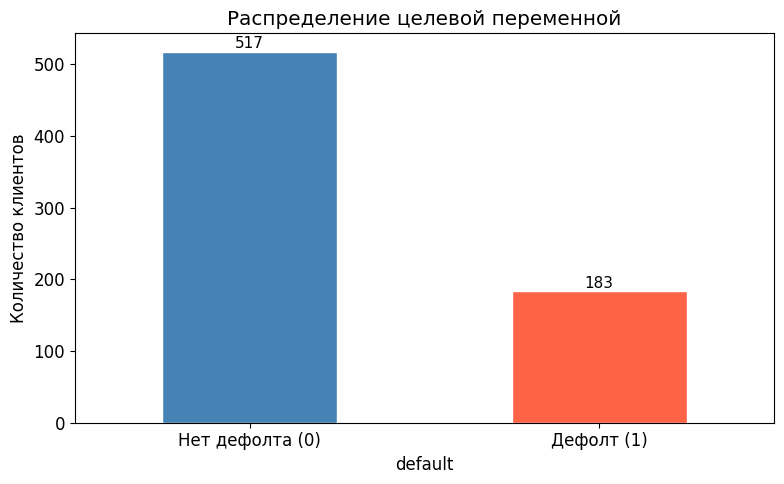

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['Нет дефолта (0)', 'Дефолт (1)'], rotation=0)
ax.set_ylabel('Количество клиентов')
ax.set_title('Распределение целевой переменной')
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 2.3 Анализ и обработка выбросов

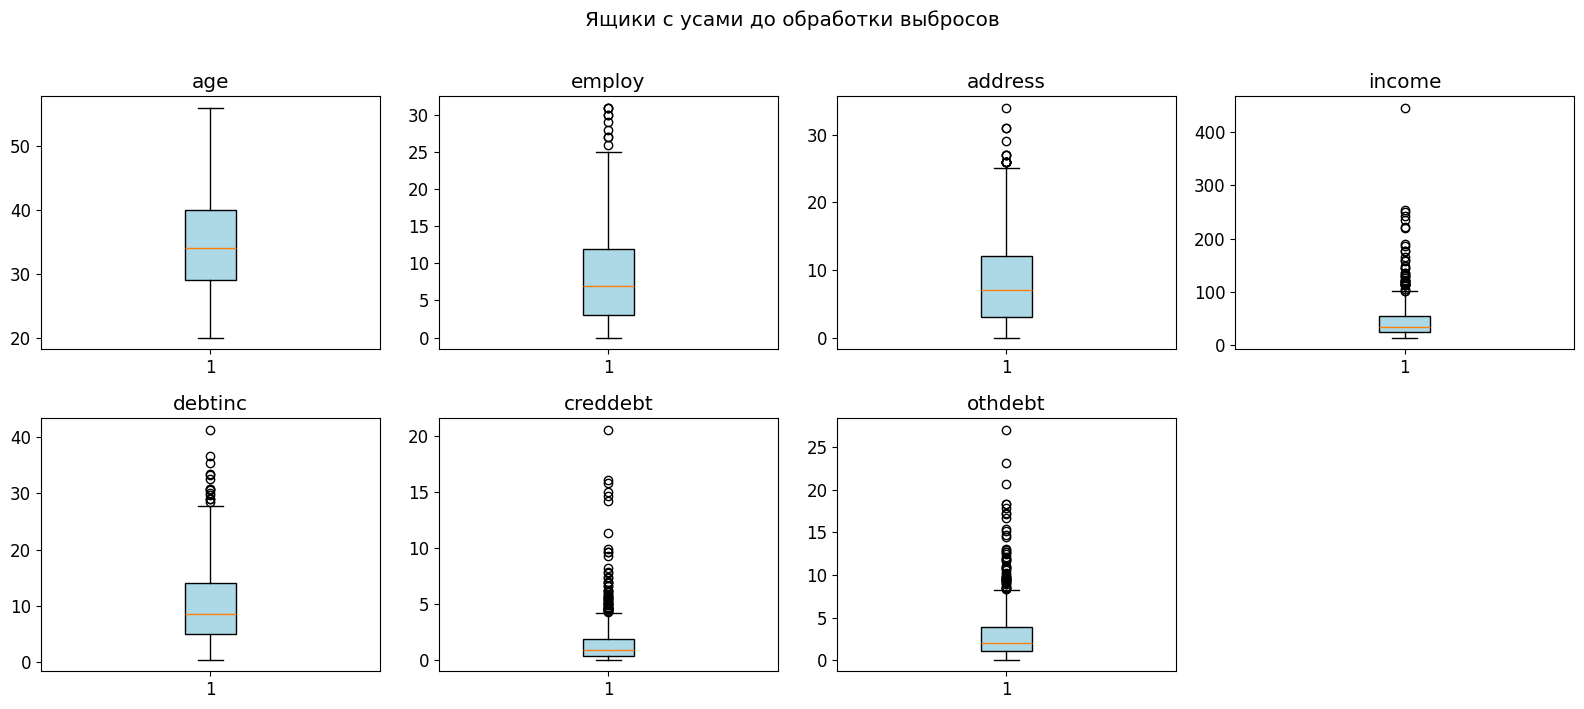

In [ ]:
numeric_cols = ['age', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
  axes[i].boxplot(df_clean[col], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
  axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Ящики с усами до обработки выбросов', y=1.01)
plt.tight_layout()
plt.show()

**Анализ графиков.** По ящикам с усами можно сделать следующие наблюдения:

- **`age`** — распределение относительно симметричное, выбросов нет. Большинство клиентов в возрасте 28–40 лет.
- **`employ`** — на графике видны точки выше верхнего уса. Однако однозначно называть их выбросами некорректно: стаж работы 25–30 лет вполне реален для клиента старше 45–50 лет. Посмотрим на совместное распределение `age` и `employ` ниже, чтобы проверить, не противоречат ли такие значения возрасту клиента.
- **`address`** — аналогично `employ`: большинство клиентов живёт по одному адресу менее 15 лет, но есть единичные значения свыше 25–30 (вполне реалистичны для пожилого клиента).
- **`income`** — наиболее выраженная ситуация: медиана невысокая (в районе 35 тыс.), однако есть клиент с доходом свыше 400 тыс.
- **`debtinc`** — основная масса значений 5-15%, но есть точки в районе 30% и выше.
- **`creddebt`** и **`othdebt`** — большинство значений меньше 5, однако присутствуют единичные экстремальные значения (15–20 и 25 соответственно).

Таким образом, выбросы присутствуют в большинстве числовых признаков и требуют обработки перед обучением моделей.

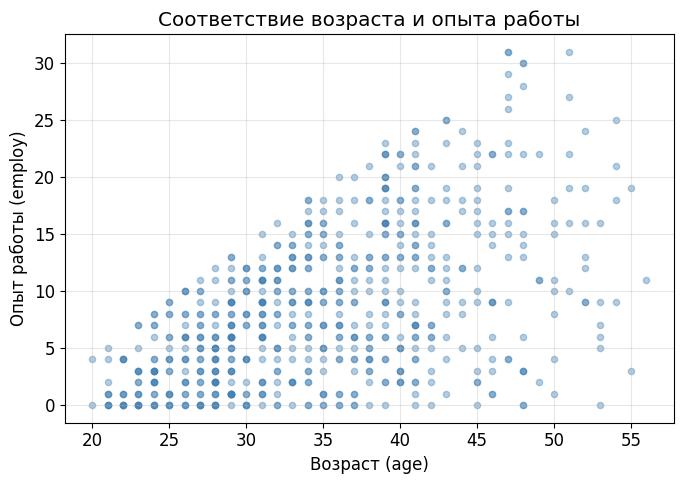

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean['age'], df_clean['employ'], alpha=0.4, s=20, color='steelblue')
ax.set_xlabel('Возраст (age)')
ax.set_ylabel('Опыт работы (employ)')
ax.set_title('Соответствие возраста и опыта работы')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

График подтверждает: высокие значения `employ` встречаются у клиентов старшего возраста — такие наблюдения физически возможны и не являются ошибками данных. Аналогичная логика применима к `address`.

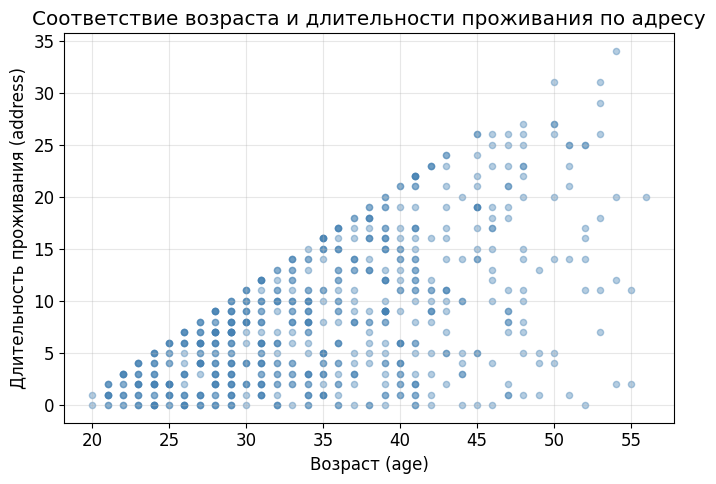

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean['age'], df_clean['address'], alpha=0.4, s=20, color='steelblue')
ax.set_xlabel('Возраст (age)')
ax.set_ylabel('Длительность проживания (address)')
ax.set_title('Соответствие возраста и длительности проживания по адресу')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Удаление выбросов методом IQR с коэффициентом 3.0 (он удаляет только экстремальные выбросы)
def remove_outliers_iqr(data, columns, factor=3.0):
  mask = pd.Series([True] * len(data), index=data.index)
  for col in columns:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    mask &= data[col].between(lower, upper)
  return data[mask]

df_filtered = remove_outliers_iqr(df_clean, numeric_cols, factor=3.0)
print(f'Строк до обработки выбросов: {len(df_clean)}')
print(f'Строк после обработки выбросов: {len(df_filtered)}')
print(f'Удалено строк: {len(df_clean) - len(df_filtered)}')

Строк до обработки выбросов:    700
Строк после обработки выбросов: 662
Удалено строк: 38


## 3. Формирование признаков и целевой переменной

In [ ]:
feature_cols = ['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']
target_col = 'default'

X = df_filtered[feature_cols].values
y = df_filtered[target_col].values

print(f'Признаков: {X.shape[1]}')
print(f'Объектов: {X.shape[0]}')
print(f'Список признаков: {feature_cols}')

Признаков: 8
Объектов:  662
Список признаков: ['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка: {X_test.shape[0]} объектов')

Обучающая выборка: 529 объектов
Тестовая выборка:  133 объектов


In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Стандартизация выполнена.')
print(f'Среднее по первому признаку (train): {X_train_sc[:, 0].mean():.4f}')
print(f'Std по первому признаку (train): {X_train_sc[:, 0].std():.4f}')

Стандартизация выполнена.
Среднее по первому признаку (train): 0.0000
Std по первому признаку (train):     1.0000


## 4. Построение моделей бинарной классификации (логистическая регрессия, SVM и дерево решений)

### 4.1 Логистическая регрессия

Логистическая регрессия — статистический метод для задач бинарной классификации. В отличие от линейной регрессии, она использует сигмоидную функцию, преобразующую линейную комбинацию признаков в вероятность от 0 до 1. Обучение происходит методом градиентного спуска путём минимизации логарифмической функции потерь (log loss).

In [ ]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_sc, y_train)

y_pred_lr  = lr_model.predict(X_test_sc)
y_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print('Логистическая регрессия — обучение завершено.')
print()
print('Коэффициенты модели (отсортированы по модулю):')
coef_df = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': lr_model.coef_[0].round(4)
}).sort_values('Коэффициент', key=abs, ascending=False)
display(coef_df)

Логистическая регрессия — обучение завершено.

Коэффициенты модели (отсортированы по модулю):


,Признак,Коэффициент
2,employ,-1.5809
6,creddebt,0.7658
3,address,-0.5740
5,debtinc,0.5318
0,age,0.3017
4,income,-0.2413
1,ed,0.1097
7,othdebt,-0.0236


Поскольку признаки стандартизированы, коэффициенты напрямую сопоставимы между собой и показывают вклад каждого признака в итоговое решение модели.

- **Положительный коэффициент** означает, что при росте признака вероятность дефолта увеличивается. Например, чем выше `debtinc` (долговая нагрузка) или `creddebt`, тем больше шансов, что клиент не выплатит кредит.
- **Отрицательный коэффициент** означает обратную зависимость: чем больше значение признака, тем ниже вероятность дефолта. Например, большой `employ` (опыт работы) снижает риск — стабильно работающий клиент более надёжен.
- **Величина** коэффициента (по модулю) отражает силу влияния: чем она больше, тем сильнее признак влияет на предсказание. Признаки с коэффициентом, близким к нулю, практически не влияют на решение модели.

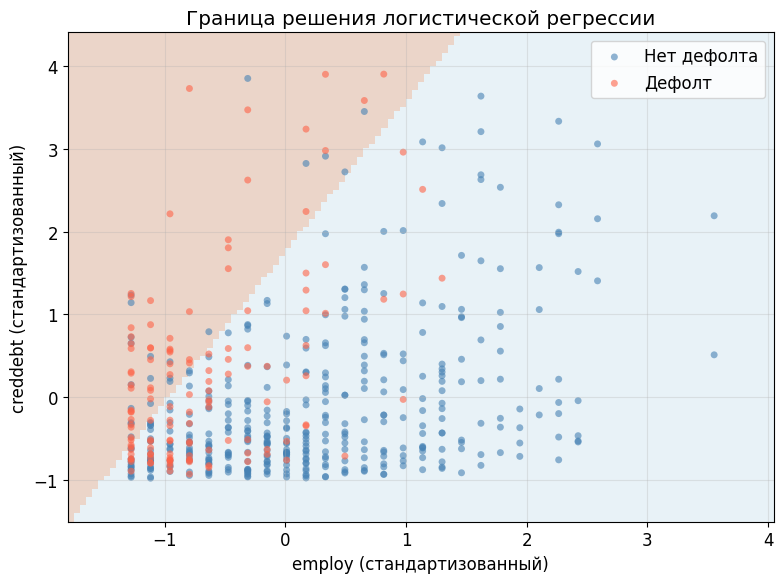

In [ ]:
# Визуализация границы решения логистической регрессии
# Берём два наиболее значимых признака по коэффициентам: employ и creddebt
emp_idx  = feature_cols.index('employ')
cred_idx = feature_cols.index('creddebt')

X2 = np.column_stack([X_train_sc[:, emp_idx], X_train_sc[:, cred_idx]])

x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

lr_2d = LogisticRegression(max_iter=1000, random_state=42)
lr_2d.fit(X2, y_train)
Z = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.25)

for cls, color, label in [(0, 'steelblue', 'Нет дефолта'), (1, 'tomato', 'Дефолт')]:
  mask = y_train == cls
  ax.scatter(X2[mask, 0], X2[mask, 1],
              color=color, label=label, alpha=0.6, s=25, edgecolors='none')

ax.set_xlabel('employ (стандартизованный)')
ax.set_ylabel('creddebt (стандартизованный)')
ax.set_title('Граница решения логистической регрессии')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

График наглядно демонстрирует природу логистической регрессии: она строит **линейную границу** (прямую) в пространстве признаков. Клиенты левее/выше границы относятся к классу «дефолт», правее/ниже — к классу «нет дефолта». Видно, что классы перекрываются, и идеально разделить их прямой невозможно — часть точек неизбежно оказывается по «не той» стороне.

### 4.2 Метод опорных векторов (SVM)

Перед выбором ядра SVM имеет смысл взглянуть на то, как классы расположены в пространстве признаков. Для наглядности визуализируем два наиболее значимых признака — `employ` и `creddebt`.

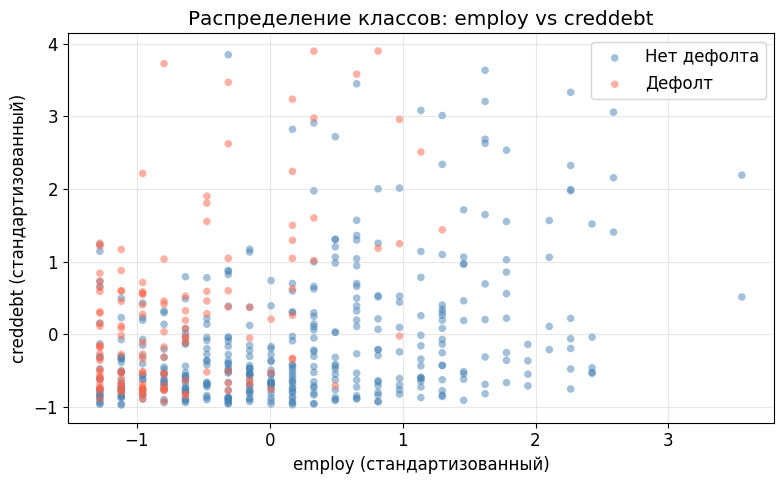

In [ ]:
# Визуализация распределения классов по двум ключевым признакам
fig, ax = plt.subplots(figsize=(8, 5))
emp_idx  = feature_cols.index('employ')
cred_idx = feature_cols.index('creddebt')

for cls, color, label in [(0, 'steelblue', 'Нет дефолта'), (1, 'tomato', 'Дефолт')]:
  mask = y_train == cls
  ax.scatter(X_train_sc[mask, emp_idx], X_train_sc[mask, cred_idx],
              c=color, label=label, alpha=0.5, s=30, edgecolors='none')

ax.set_xlabel('employ (стандартизованный)')
ax.set_ylabel('creddebt (стандартизованный)')
ax.set_title('Распределение классов: employ vs creddebt')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Как видно из графика, классы **не разделяются прямой линией**: точки обоих классов перемешаны и перекрываются в центральной области. Линейное ядро в такой ситуации даст плохую границу решения. Поэтому применим **RBF-ядро (Radial Basis Function)** — оно неявно преобразует данные в пространство более высокой размерности, где классы уже могут быть разделены нелинейной границей.

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=42)
svm_model.fit(X_train_sc, y_train)

y_pred_svm  = svm_model.predict(X_test_sc)
y_proba_svm = svm_model.predict_proba(X_test_sc)[:, 1]

print('SVM (ядро RBF) — обучение завершено.')
print(f'Количество опорных векторов: {sum(svm_model.n_support_)}')
print(f'(из них класс 0: {svm_model.n_support_[0]}, класс 1: {svm_model.n_support_[1]})')

SVM (ядро RBF) — обучение завершено.
Количество опорных векторов: 321
(из них класс 0: 231, класс 1: 90)


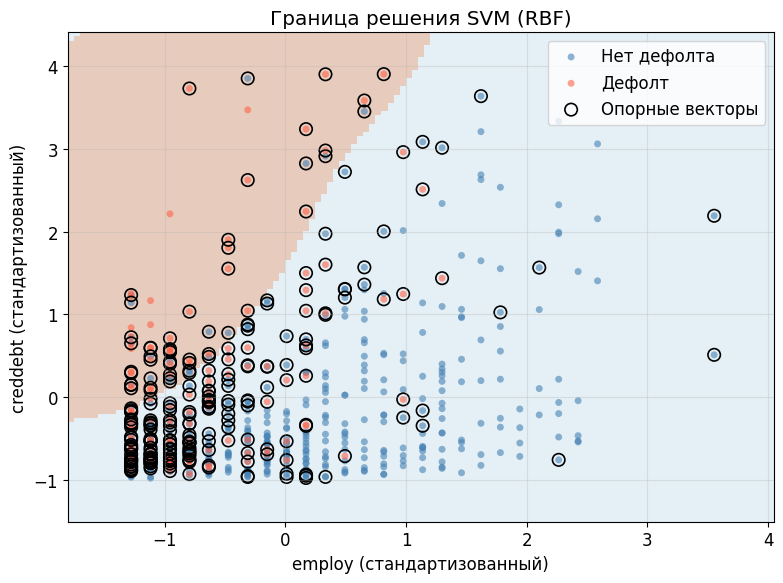

In [ ]:
# Визуализация границы решения SVM
svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
X2_train_svm = np.column_stack([X_train_sc[:, emp_idx], X_train_sc[:, cred_idx]])
X2_test_svm  = np.column_stack([X_test_sc[:, emp_idx],  X_test_sc[:, cred_idx]])
svm_2d.fit(X2_train_svm, y_train)

x_min, x_max = X2_train_svm[:, 0].min() - 0.5, X2_train_svm[:, 0].max() + 0.5
y_min, y_max = X2_train_svm[:, 1].min() - 0.5, X2_train_svm[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z_svm = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(xx, yy, Z_svm, cmap=plt.cm.Paired, alpha=0.3)

for cls, color, label in [(0, 'steelblue', 'Нет дефолта'), (1, 'tomato', 'Дефолт')]:
  mask = y_train == cls
  ax.scatter(X2_train_svm[mask, 0], X2_train_svm[mask, 1],
              color=color, label=label, alpha=0.6, s=25, edgecolors='none')

sv = svm_2d.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none',
           edgecolors='black', linewidths=1.2, label='Опорные векторы')

ax.set_xlabel('employ (стандартизованный)')
ax.set_ylabel('creddebt (стандартизованный)')
ax.set_title('Граница решения SVM (RBF)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

В отличие от логистической регрессии, SVM с RBF-ядром строит **нелинейную границу**: она изгибается, подстраиваясь под фактическое расположение классов.

### 4.3 Дерево решений (CART)

In [ ]:
# Подбор гиперпараметров эмпирически
depths = range(1, 11)
f1_scores = []
for d in depths:
    model = DecisionTreeClassifier(max_depth=d,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred)
    f1_scores.append(score)

Text(0.5, 1.0, 'Зависимость качества модели от глубины дерева')

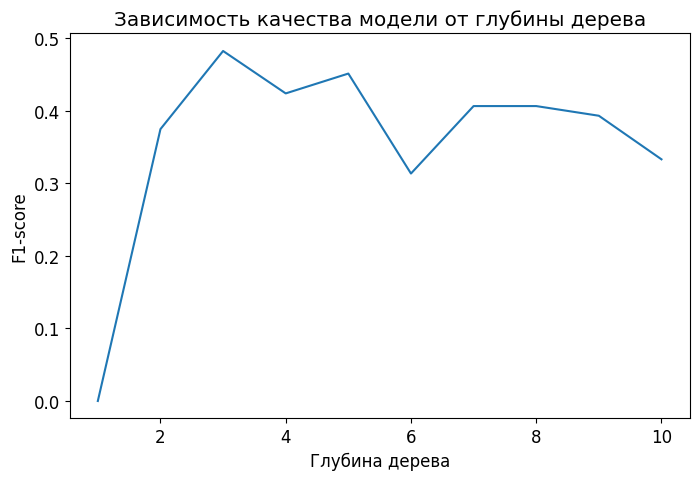

In [ ]:
plt.plot(depths, f1_scores)
plt.xlabel("Глубина дерева")
plt.ylabel("F1-score")
plt.title("Зависимость качества модели от глубины дерева")

Наилучшее значение метрики F1-score достигается при глубине дерева, равной 3.
При дальнейшем увеличении глубины наблюдается снижение качества модели, что может свидетельствовать о переобучении.
Поэтому в дальнейшем используется модель с глубиной дерева 3.

In [ ]:
#Эксперименты с поиком лучшего min_samples_leaf
leaf_values = [1, 5, 10, 15, 20, 30]
f1_scores = []
for leaf in leaf_values:
    model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred)
    f1_scores.append(score)

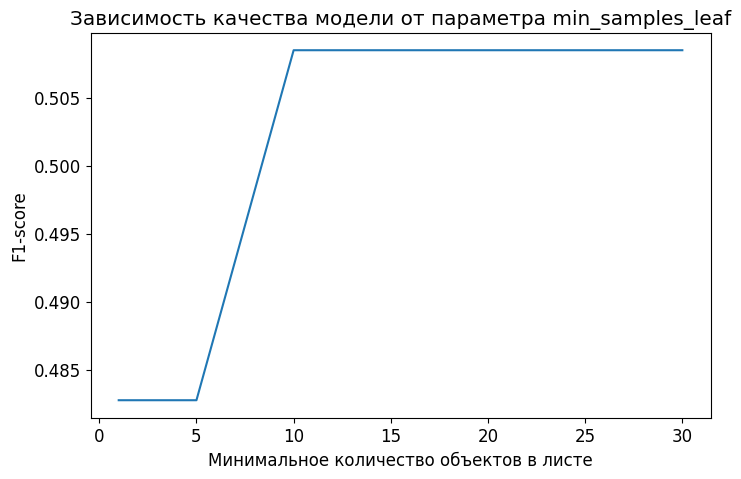

In [ ]:
plt.plot(leaf_values, f1_scores)
plt.xlabel("Минимальное количество объектов в листе")
plt.ylabel("F1-score")
plt.title("Зависимость качества модели от параметра min_samples_leaf")
plt.show()

На графике видно, что значение метрики F1-score увеличивается при росте параметра min_samples_leaf до 10, после чего остаётся неизменным.
Поскольку дальнейшее увеличение параметра не приводит к улучшению качества модели, оптимальным считается минимальное значение параметра, при котором достигается максимальная метрика.
Таким образом, для построения итоговой модели выбрано значение min_samples_leaf = 10.

In [ ]:
cart_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, class_weight='balanced', random_state=42)
cart_model.fit(X_train_sc, y_train)

y_pred_cart  = cart_model.predict(X_test_sc)
y_proba_cart = cart_model.predict_proba(X_test_sc)[:, 1]

print('Дерево решений (CART) — обучение завершено.')
print(f'Глубина дерева: {cart_model.get_depth()}')
print(f'Количество листьев: {cart_model.get_n_leaves()}')

Дерево решений (CART) — обучение завершено.
Глубина дерева:     3
Количество листьев: 8


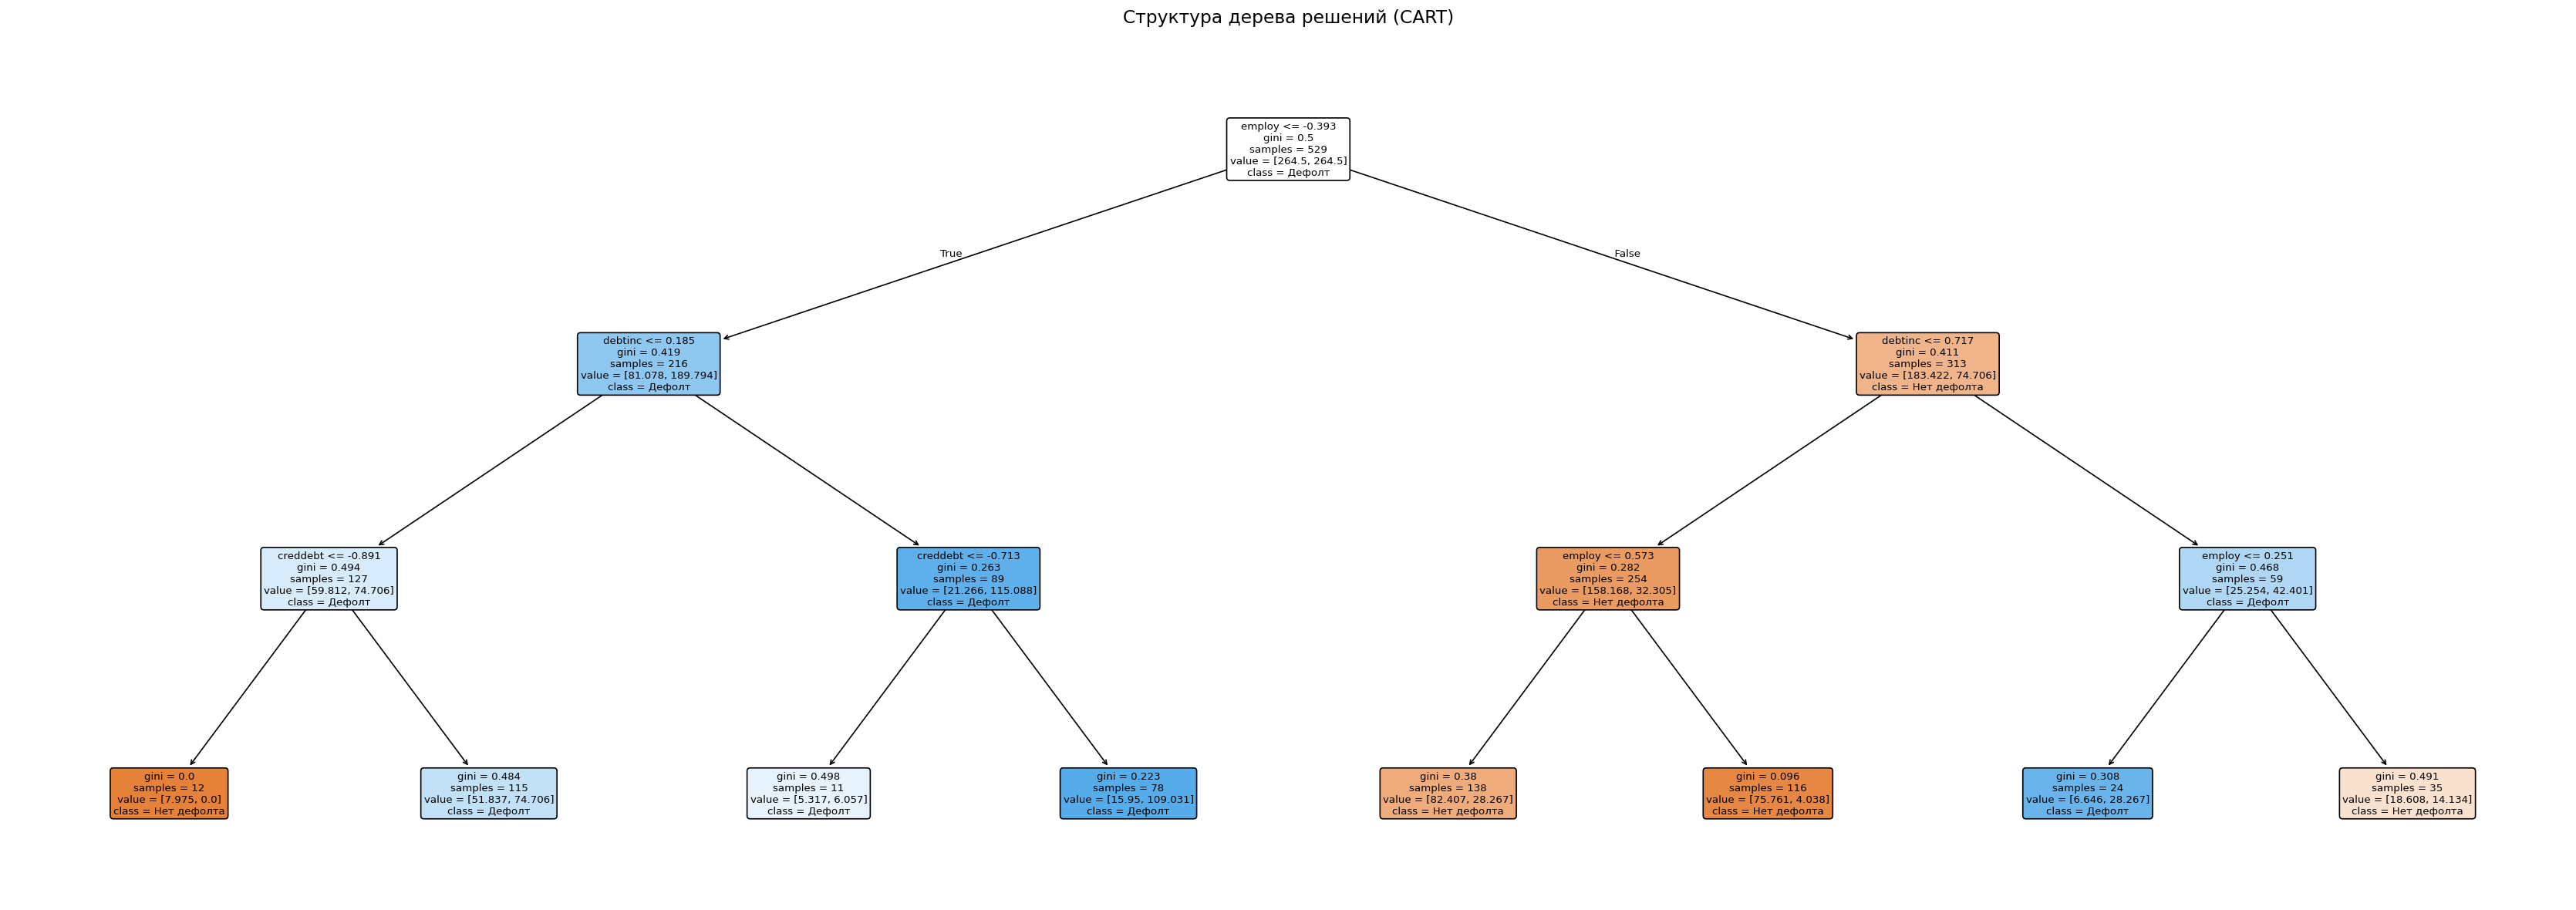

In [ ]:
# Визуализация дерева решений
fig, ax = plt.subplots(figsize=(28, 10), dpi=120)
plot_tree(cart_model, feature_names=feature_cols, class_names=['Нет дефолта', 'Дефолт'], filled=True, rounded=True, fontsize=8, ax=ax, impurity=True, precision=3)
ax.set_title('Структура дерева решений (CART)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Анализ структуры дерева.** Дерево начинает разбивку с признака `employ` — это корневой узел, то есть именно стаж работы является наиболее информативным признаком для первичного разделения клиентов. Клиенты с небольшим стажем попадают в левую ветку, где далее дерево анализирует `debtinc` и `creddebt`. Клиенты с большим стажем уходят в правую ветку — там долговая нагрузка также играет ключевую роль, затем повторно анализируется трудовой стаж.

В каждом узле указаны: условие разбивки, критерий Джини (мера неоднородности узла — чем ближе к 0, тем чище разделение), число объектов и распределение по классам. Листовые узлы содержат итоговый класс — тот, который преобладает среди объектов, дошедших до данного листа.

## 5. Оценка качества моделей

### 5.1 Сводная таблица метрик

Для оценки используется набор стандартных метрик классификации:

- **Accuracy** — доля верных предсказаний от общего числа. При дисбалансе классов может быть неинформативной, ненадежной метрикой.
- **Precision (точность)** — из всех клиентов, которых модель отнесла к "дефолтникам", какая доля действительно ими является. Важна, когда ложная тревога дорого обходится.
- **Recall (полнота)** — из всех реальных дефолтников, какую долю модель смогла выявить. В банковском скоринге критически важна: пропущенный дефолтник — прямые убытки.
- **F1-score** — гармоническое среднее Precision и Recall. Полезен при дисбалансе классов как единая сбалансированная метрика.
- **ROC-AUC** — площадь под ROC-кривой. Показывает, насколько хорошо модель разделяет классы при любом пороге. Значение 0.5 — случайная модель, 1.0 — идеальная.

In [ ]:
def compute_metrics(y_true, y_pred, y_proba):
  return {
      'Accuracy': round(accuracy_score(y_true, y_pred), 4),
      'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
      'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
      'F1-score': round(f1_score(y_true, y_pred, zero_division=0), 4),
      'ROC-AUC': round(roc_auc_score(y_true, y_proba), 4),
  }

results = {
    'Логистическая регрессия': compute_metrics(y_test, y_pred_lr, y_proba_lr),
    'SVM (RBF)': compute_metrics(y_test, y_pred_svm, y_proba_svm),
    'Дерево решений (CART)': compute_metrics(y_test, y_pred_cart, y_proba_cart),
}

results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Логистическая регрессия,0.6917,0.4259,0.6970,0.5287,0.7888
SVM (RBF),0.6842,0.4262,0.7879,0.5532,0.7591
Дерево решений (CART),0.6316,0.3750,0.7273,0.4948,0.7212


**Анализ таблицы метрик.**

* По **Accuracy** наилучший результат показывает логистическая регрессия (~0.
692), однако значения у всех моделей близкие. При наличии дисбаланса классов данная метрика не всегда отражает реальное качество модели.

* По **Precision** результаты моделей находятся примерно на одном уровне (~0.375–0.426), что означает, что при предсказании дефолта модели оказываются правы примерно в 38–43% случаев.

* По **Recall** наилучший результат показывает модель метода опорных векторов (~ 0.788). Это означает, что модель успешно выявляет около 79% клиентов с дефолтом. Логистическая регрессия (~ 0.697) и дерево решений (~ 0.727) также демонстрируют достаточно высокую способность обнаруживать объекты редкого класса.

* По **F1-score** наилучшее значение также наблюдается у SVM (~0.553), что свидетельствует о наиболее сбалансированном качестве классификации среди рассмотренных моделей.

* По **ROC-AUC** лучший результат показывает логистическая регрессия (~0.789), что говорит о её хорошей способности различать классы.

**Вывод:**

В целом все модели показывают сопоставимые результаты. Наиболее эффективной можно считать **модель SVM**, так как она демонстрирует лучшие значения Recall и F1-score.
Логистическая регрессия также показывает высокий результат по метрике ROC-AUC и может рассматриваться как надежная модель для решения задачи классификации.

### 5.2 Матрицы ошибок

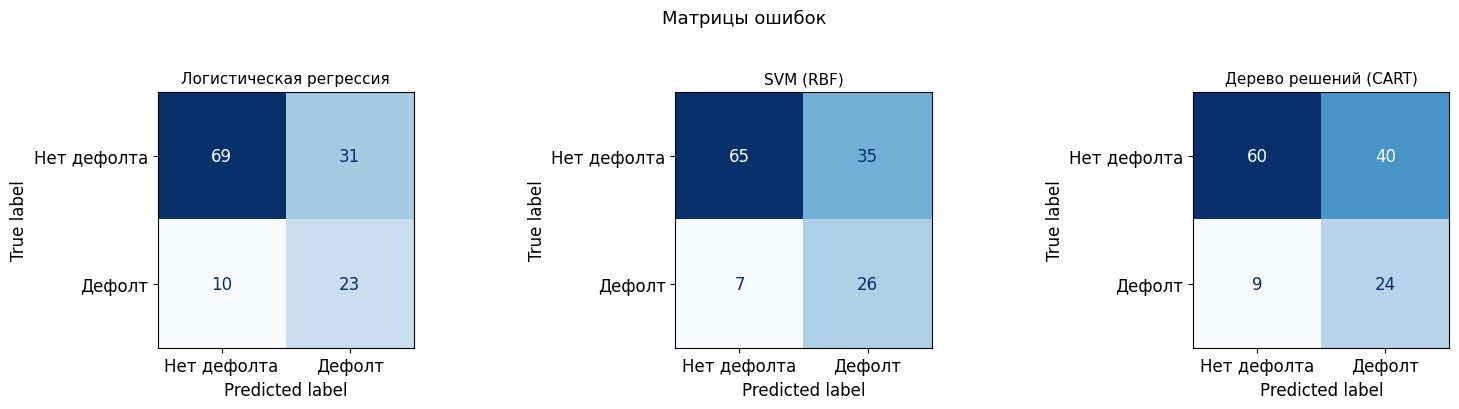

In [ ]:
models_info = [
    ('Логистическая регрессия', y_pred_lr),
    ('SVM (RBF)', y_pred_svm),
    ('Дерево решений (CART)', y_pred_cart),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, models_info):
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(cm, display_labels=['Нет дефолта', 'Дефолт'])
  disp.plot(ax=ax, colorbar=False, cmap='Blues')
  ax.set_title(name, fontsize=11)
plt.suptitle('Матрицы ошибок', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Матрица ошибок разбивает все предсказания на четыре категории:
- **TN (верхний левый)** — клиент надёжный, и модель правильно это предсказала.
- **FP (верхний правый)** — клиент надёжный, но модель ошибочно записала его в дефолтники (ошибка 1-го рода — ложная тревога).
- **FN (нижний левый)** — клиент реально допустит дефолт, но модель этого не заметила (ошибка 2-го рода). **Для банка это наиболее опасная ошибка: выдан кредит ненадёжному клиенту.**
- **TP (нижний правый)** — клиент-дефолтник правильно опознан моделью.

Для модели **логистической регрессии** 69 клиентов без дефолта были правильно определены как надёжные, а 23 клиента с дефолтом — как рискованные. Однако 10 клиентов с дефолтом модель не выявила, то есть банк мог бы выдать кредит таким клиентам и понести убытки. В то же время 31 надёжный клиент был ошибочно отнесён к группе риска, что могло привести к отказу в кредите потенциально хорошим клиентам.

**Метод опорных векторов** выявил 26 клиентов с дефолтом и пропустил только 7 таких клиентов — это наименьшее значение среди всех моделей. С практической точки зрения это означает, что **данная модель лучше всего защищает банк от выдачи кредитов ненадёжным клиентам.** Однако количество ложных тревог (35) немного выше, чем у логистической регрессии, то есть больше надёжных клиентов могут получить отказ.

**Дерево решений** выявило 24 клиента с дефолтом и пропустило 9 таких клиентов. При этом модель ошибочно отнесла к группе риска 40 надёжных клиентов — это наибольшее значение среди всех моделей. На практике это означает б**олее жёсткую политику отказов** и возможную потерю части клиентов.

**Вывод:**

С практической точки зрения **метод опорных векторов** обеспечивает наилучшую защиту от финансовых потерь, так как выявляет наибольшее количество клиентов с дефолтом, тогда как логистическая регрессия позволяет снизить количество необоснованных отказов надёжным клиентам.

### 5.3 ROC-кривые

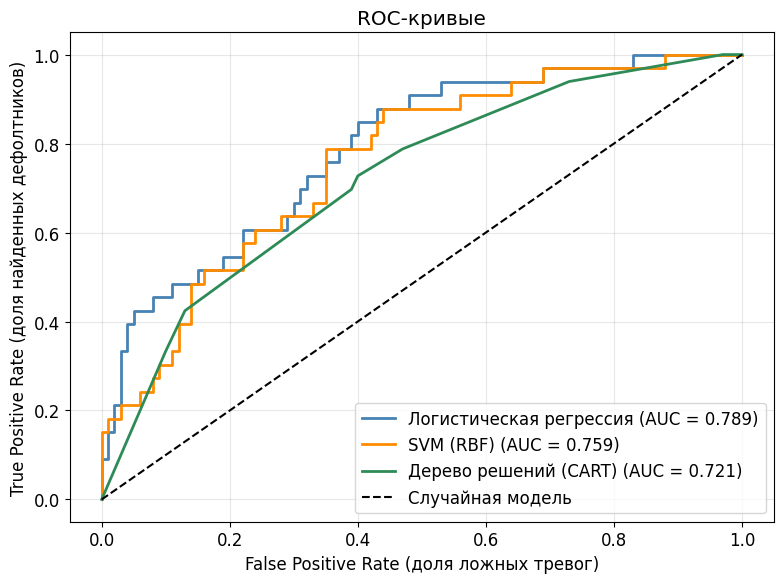

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'darkorange', 'seagreen']
for (name, _), proba, color in zip(models_info,
                                  [y_proba_lr, y_proba_svm, y_proba_cart],
                                  colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайная модель')
ax.set_xlabel('False Positive Rate (доля ложных тревог)')
ax.set_ylabel('True Positive Rate (доля найденных дефолтников)')
ax.set_title('ROC-кривые')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ROC-кривая строится путём перебора всех возможных порогов классификации (от 0 до 1). При каждом пороге вычисляются TPR (True Positive Rate — доля реальных дефолтников, которых модель нашла) и FPR (False Positive Rate — доля надёжных клиентов, ошибочно отнесённых к дефолтникам). Пара (FPR, TPR) даёт одну точку на кривой.

- **Пунктирная диагональ** — «случайная модель» (AUC = 0.5): предсказывает наугад.
- **Идеальная модель** имеет AUC = 1.0 и проходит через верхний левый угол.
- Чем дальше кривая от диагонали, тем лучше модель.

**Выводы по графику:** логистическая регрессия (AUC=0.789) лучше всех отделяет дефолтников от надёжных клиентов при разных порогах. SVM (AUC=0.759) уступает.  Дерево решений (AUC=0.721) хуже ранжирует клиентов по вероятности риска.

### 5.4 Сравнение метрик

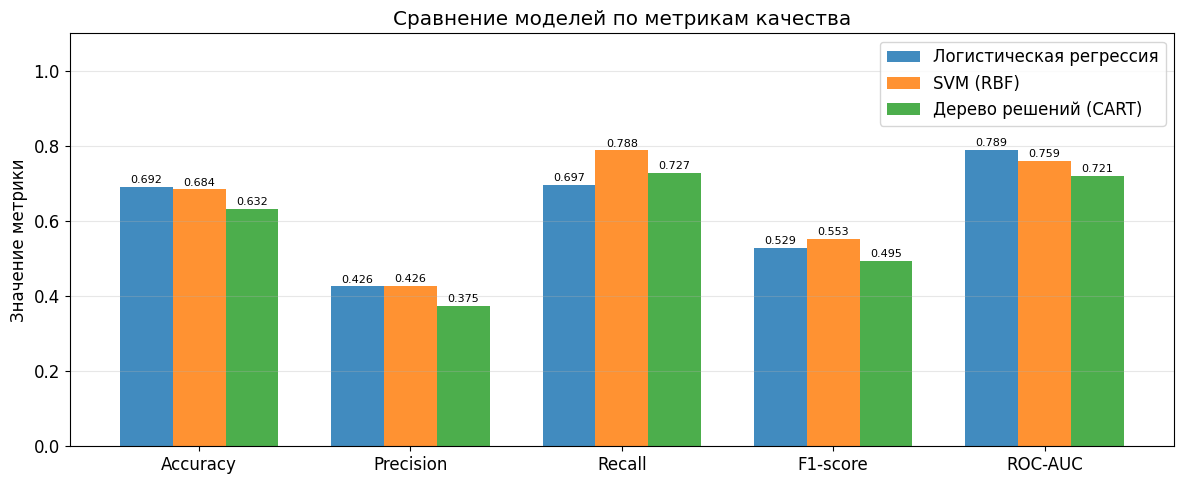

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(results_df.iterrows()):
  offset = (i - 1) * width
  bars = ax.bar(x + offset, [row[m] for m in metrics_to_plot],
                width, label=model_name, alpha=0.85)
  for bar in bars:
      h = bar.get_height()
      ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
              f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей по метрикам качества')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Диаграмма наглядно подтверждает выводы из таблицы метрик. По Recall и F1-score SVM выглядит предпочтительнее, однако ROC-AUC немного выше у логистической регрессии.

### 5.5 Важность признаков

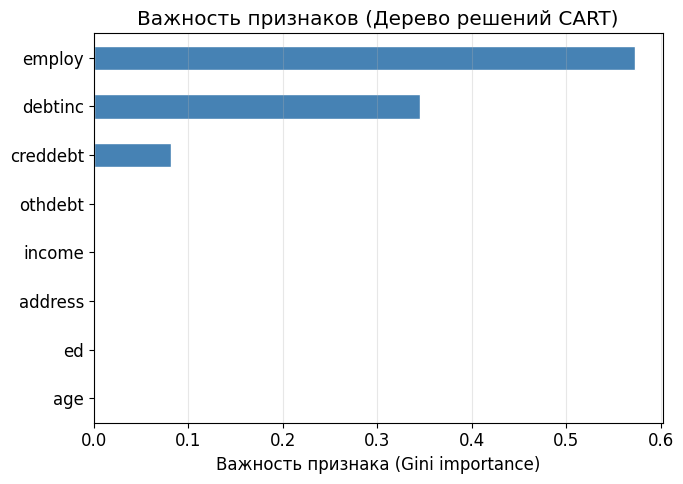

In [ ]:
importances = cart_model.feature_importances_
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
feat_importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Важность признака (Gini importance)')
ax.set_title('Важность признаков (Дерево решений CART)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Важность признаков в дереве решений (Gini importance) показывает, насколько сильно каждый признак снижает неоднородность (критерий Джини) при разбивке узлов. Чем чаще и эффективнее признак используется в дереве, тем выше его важность. Сумма всех важностей равна 1.

- **`employ` (опыт работы)** — безусловный лидер с важностью ~0.57. Это согласуется со структурой дерева: именно этот признак использован в корневом узле. Стаж работы напрямую связан с финансовой стабильностью клиента.
- **`debtinc`** — второй по значимости (~0.33).
- **`creddebt`** — умеренное влияние.
- Остальные признаки практически не используются деревом (важность близка к нулю), что говорит об их слабой предсказательной силе в данной задаче.

Таким образом, банку при оценке кредитного риска в первую очередь следует обращать внимание на трудовой стаж клиента и его текущую долговую нагрузку — именно эти факторы наиболее информативны для предсказания дефолта.

# 6. Выводы




*   Из-за дисбаланса выборки (76% (нет дефолта) и 24% (дефолт)) для повышения качества моделей применяется гиперпараметр class_weight='balanced'.
*   Наиболее значимые факторы при оценке кредитного риска - `employ` (опыт работы), `creddebt` (задолженность по кредиту) и `debtinc` (долговая нагрузка).
*   SVM лидирует по Recall (0.788) и F1-score (0.553). По ROC-AUC лучший результат у логистической регрессии (0.789), что делает её предпочтительной для ранжирования клиентов по риску. Дерево решений уступает по всем метрикам.